LAB: PART A - Activation Function Visualization

Gowtham S - 24BAD028


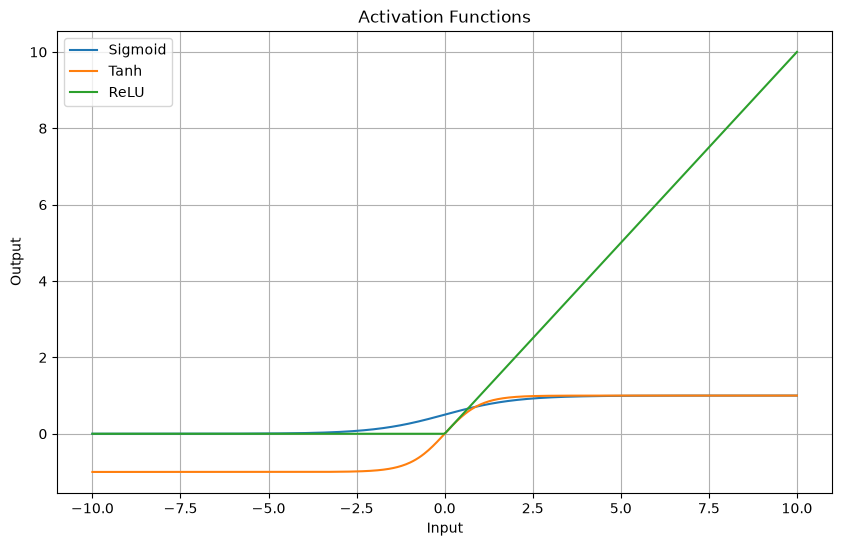

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Gowtham S - 24BAD028")

x = np.linspace(-10,10,500)

# Activation Functions
sigmoid = 1/(1+np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0,x)

plt.figure(figsize=(10,6))

plt.plot(x,sigmoid,label="Sigmoid")
plt.plot(x,tanh,label="Tanh")
plt.plot(x,relu,label="ReLU")

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()

plt.show()

LAB: PART B - Activation Function Comparison


In [2]:
print("Gowtham S - 24BAD028")

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

# Load Dataset
(x_train,y_train),(x_test,y_test)=mnist.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

activation_functions=["sigmoid","tanh","relu"]

histories={}

for activation in activation_functions:

    model=Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128,activation=activation),
        Dense(64,activation=activation),
        Dense(10,activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print("\nTraining using:",activation)

    history=model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=128,
        verbose=1
    )

    histories[activation]=history

    test_loss,test_acc=model.evaluate(x_test,y_test,verbose=0)

    print("Test Accuracy:",test_acc)

Gowtham S - 24BAD028


c:\Users\HP\anaconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training using: sigmoid
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7947 - loss: 0.8874 - val_accuracy: 0.9116 - val_loss: 0.3547
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9181 - loss: 0.3022 - val_accuracy: 0.9337 - val_loss: 0.2411
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9358 - loss: 0.2256 - val_accuracy: 0.9451 - val_loss: 0.1969
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9477 - loss: 0.1837 - val_accuracy: 0.9515 - val_loss: 0.1737
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9552 - loss: 0.1536 - val_accuracy: 0.9559 - val_loss: 0.1530
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9628 - loss: 0.1301 - val_accuracy: 0.9606 - val_loss: 0.1365
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9672 - loss: 0.1119 - val_accuracy: 0.9628 - val_loss: 0.1250
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9728 - loss: 

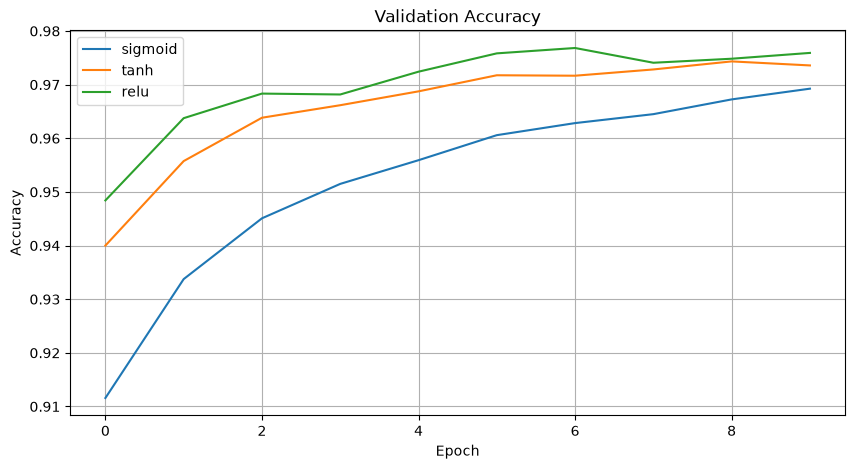

In [3]:
plt.figure(figsize=(10,5))

for activation in activation_functions:
    plt.plot(histories[activation].history['val_accuracy'],
             label=activation)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

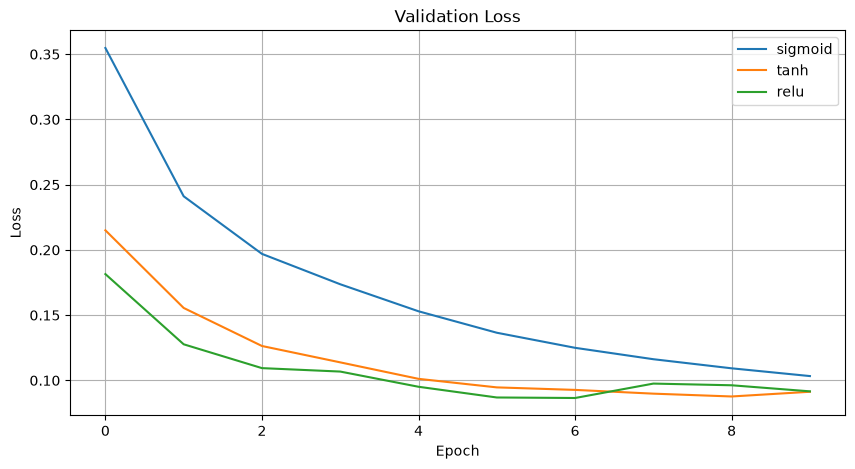

In [4]:
plt.figure(figsize=(10,5))

for activation in activation_functions:
    plt.plot(histories[activation].history['val_loss'],
             label=activation)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

LAB: PART C - Optimizer Comparison

In [5]:
print("Gowtham S - 24BAD028")

from tensorflow.keras.optimizers import SGD,RMSprop,Adam

optimizers={
    "SGD":SGD(learning_rate=0.01),
    "Momentum":SGD(learning_rate=0.01,momentum=0.9),
    "RMSProp":RMSprop(learning_rate=0.001),
    "Adam":Adam(learning_rate=0.001)
}

optimizer_history={}

for name,opt in optimizers.items():

    model=Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128,activation="relu"),
        Dense(64,activation="relu"),
        Dense(10,activation="softmax")
    ])

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print("\nTraining using:",name)

    history=model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=128,
        verbose=1
    )

    optimizer_history[name]=history

Gowtham S - 24BAD028

Training using: SGD
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6018 - loss: 1.4589 - val_accuracy: 0.8391 - val_loss: 0.7485
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8536 - loss: 0.5948 - val_accuracy: 0.8852 - val_loss: 0.4494
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8855 - loss: 0.4329 - val_accuracy: 0.9007 - val_loss: 0.3670
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8973 - loss: 0.3723 - val_accuracy: 0.9092 - val_loss: 0.3289
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9043 - loss: 0.3390 - val_accuracy: 0.9143 - val_loss: 0.3060
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9108 - loss: 0.3163 - val_accuracy: 0.9187 - val_loss: 0.2884
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9149 - loss: 0.2994 - val_accuracy: 0.9236 - val_loss: 0.2745
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy

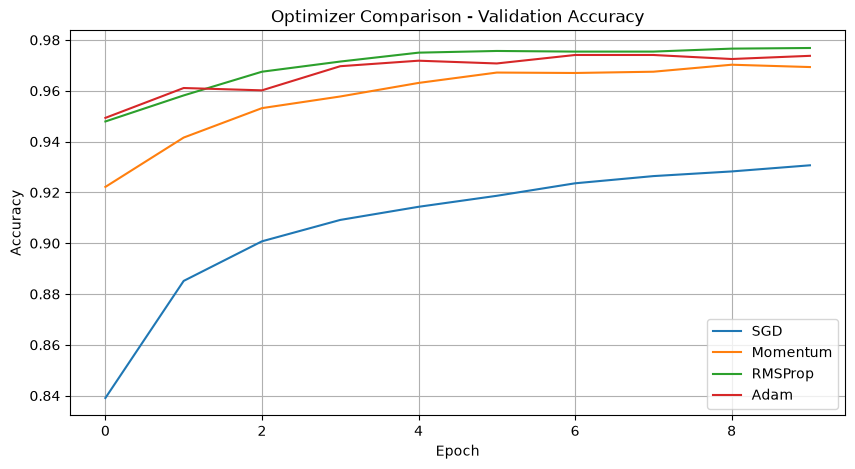

In [6]:
plt.figure(figsize=(10,5))

for name in optimizer_history:
    plt.plot(
        optimizer_history[name].history["val_accuracy"],
        label=name
    )

plt.title("Optimizer Comparison - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

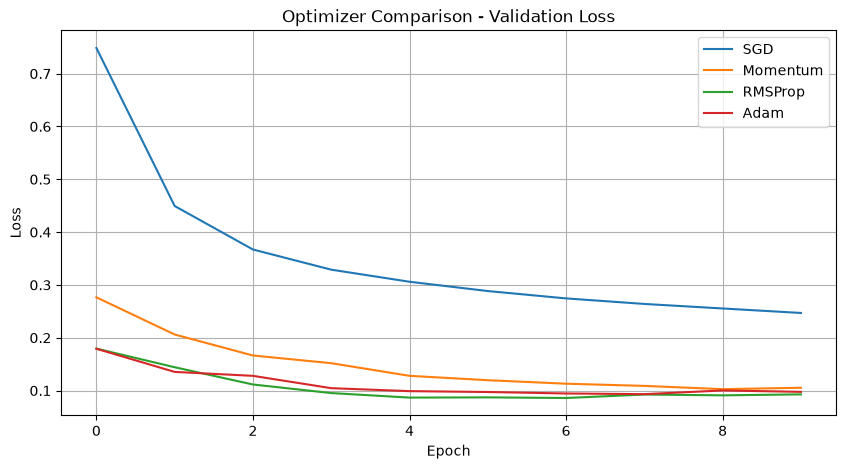

In [7]:
plt.figure(figsize=(10,5))

for name in optimizer_history:
    plt.plot(
        optimizer_history[name].history["val_loss"],
        label=name
    )

plt.title("Optimizer Comparison - Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()